In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [6]:
C1, Ceq=np.loadtxt("true.dat", unpack=True)
np.random.seed(100)
C1.shape, Ceq.shape

((1000,), (1000,))

In [7]:
C1off= C1+np.random.normal(0, 0.5, len(C1))
Ceqoff= Ceq+np.random.normal(0, 0.5, len(C1))
np.savetxt("offset.dat", [C1off, Ceqoff])

In [8]:
# C1off, Ceqoff=np.loadtxt("offset.dat", unpack=True)
def curve(x, a, b):
    return 1./(1./(x+a) +b)
popt, pcov = curve_fit(curve, C1, Ceq )
a_right, b_right= popt
err_right=np.sqrt(np.diag(pcov))
popt, pcov = curve_fit(curve, C1off, Ceqoff, p0=[a_right, b_right], )
a_fit, b_fit = popt
perr = np.sqrt(np.diag(pcov))
print(f"\n--- curve_fit ---")
print(f"a = {a_fit:.4f} ± {perr[0]:.4f}  (expected: {a_right:.4f}±{err_right[0]:.4f})")
print(f"b = {b_fit:.6f} ± {perr[1]:.6f}  (expected: {b_right:.4f}±{err_right[1]:.4f})")



--- curve_fit ---
a = 10.1022 ± 0.1450  (expected: 10.0000±0.0000)
b = 0.050023 ± 0.000087  (expected: 0.0500±0.0000)


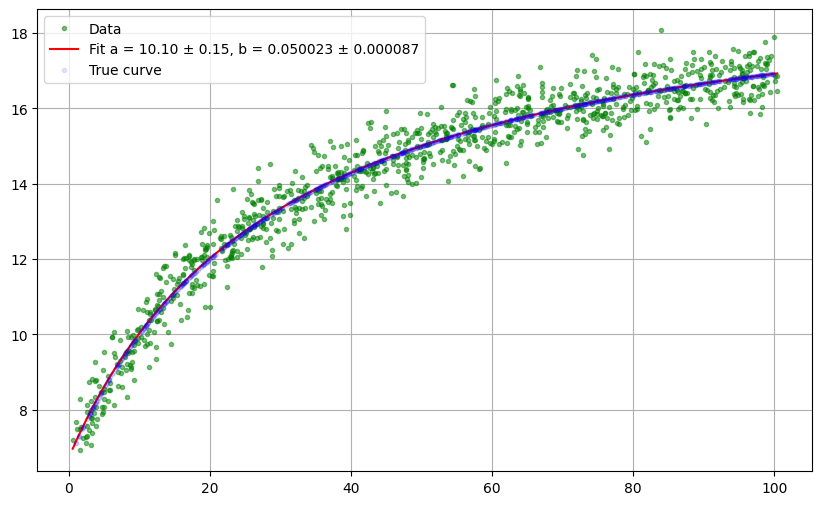

In [9]:
x_plot = np.linspace(C1off.min(), C1off.max(), 300)

plt.figure(figsize=(10, 6))
plt.plot(C1off, Ceqoff, '.g', ls='', alpha=0.5, label="Data")
plt.plot(x_plot, curve(x_plot, a_fit, b_fit), label=f'Fit a = {a_fit:.2f} ± {perr[0]:.2f}, b = {b_fit:.6f} ± {perr[1]:.6f}', color='red')
plt.plot(C1, Ceq, '.', ls='', alpha=0.1, label="True curve", color='blue')
plt.grid(), plt.legend()
plt.show()


In [10]:
C1_err=np.array(C1)
Ceq_err=np.array(Ceq)
DCeq_err=np.abs(np.random.normal(0, 3., len(Ceq)))
np.savetxt("errorbar.dat", [C1_err, Ceq_err, DCeq_err])
print(C1_err.shape, Ceq_err.shape, DCeq_err.shape)


(1000,) (1000,) (1000,)


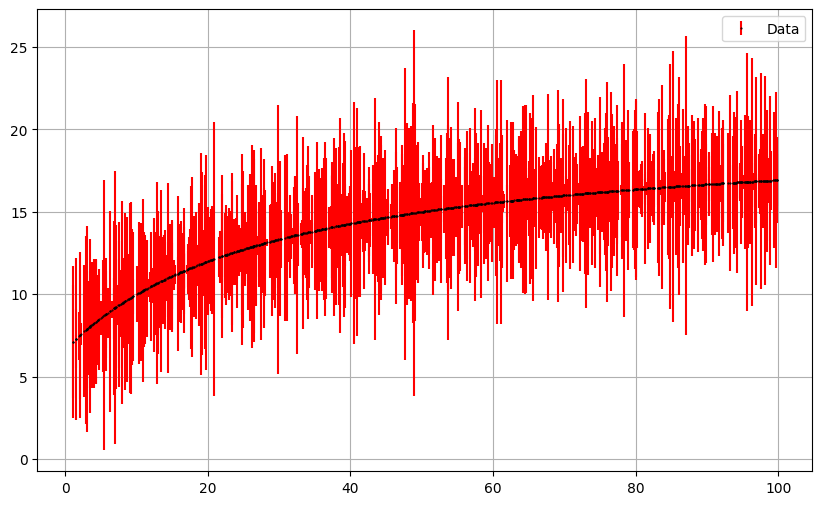

In [11]:
plt.figure(figsize=(10, 6))
plt.errorbar(C1_err, Ceq_err, DCeq_err, fmt='.k', ecolor='r', ms=1, ls='', label='Data')
plt.grid(), plt.legend(),
plt.show()


In [12]:
import emcee

100%|██████████| 5000/5000 [00:26<00:00, 190.76it/s]


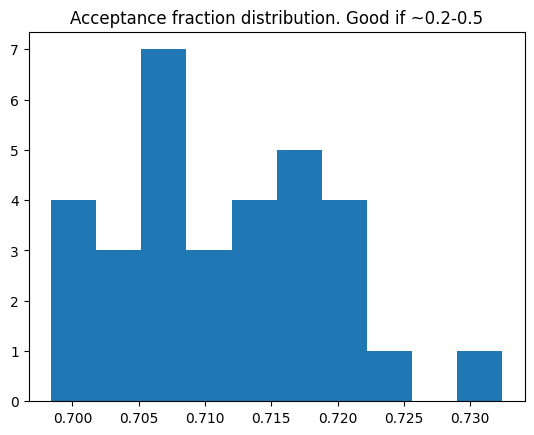

Autocorrelatio time: [35.4305557  23.91991382]

--- MCMC (emcee) ---
a = 9.9991 +0.0332 -0.0326  (expected: 10.0000±0.0000)
b = 0.050000 +0.000014 -0.000014  (expected: 0.0500±0.0000)


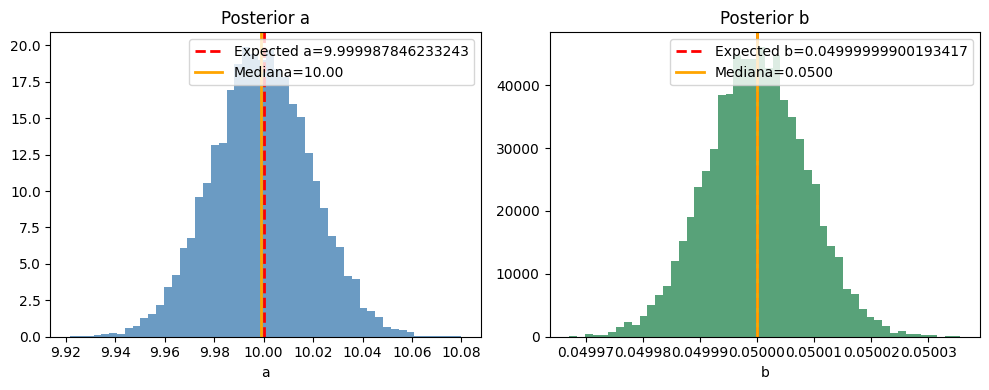

In [16]:

# ─────────────────────────────────────────────
# 4. MCMC con emcee: C̃1 vs Ceq ± ΔCeq
# ─────────────────────────────────────────────
x_mc   = C1_err
y_mc   = Ceq_err
err_mc = DCeq_err

def log_prior(theta):
    a, b = theta
    if 0 < a < 100 and 0 < b < 1:
        return 0.0
    return -np.inf

def log_likelihood(theta, x, y, yerr):
    a, b = theta
    pred = curve(x, a, b)
    return -0.5 * np.sum(((y - pred) / yerr)**2 +np.log(2*np.pi * yerr**2))

def log_posterior(theta, x, y, yerr): #log probability 
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

nwalkers, ndim = 32, 2
step_nmcmc=5000
p0 = np.array([a_fit, b_fit]) + 1e-3 * np.random.normal(size=(nwalkers, ndim))

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior,
                                 args=(x_mc, y_mc, err_mc))
sampler.run_mcmc(p0, step_nmcmc, progress=True)

plt.hist(sampler.acceptance_fraction)
# Restituisce la frazione di passi accettati nel metodo Metropolis-Hastings
# 1) Ad ogni step si propone un nuovo set di parametri
# 2) Si confronta la probabilità posteriore del nuovo vs vecchio stato
# 3) Se la probabilità è migliore (o abbastanza buona per caso), il passo è accettato e il walker si muove
# 4) Se no, il passo è rifiutato e il walker rimane dov'era
plt.title("Acceptance fraction distribution. Good if ~0.2-0.5");
# dir(sampler.acceptance_fraction)
plt.show()
tau = sampler.get_autocorr_time()
print("Autocorrelatio time:", tau)

samples = sampler.get_chain(discard=500, thin=int(np.mean(tau)/2), flat=True)

a_mcmc = np.percentile(samples[:, 0], [5, 50, 95])
b_mcmc = np.percentile(samples[:, 1], [5, 50, 95])

print(f"\n--- MCMC (emcee) ---")
print(f"a = {a_mcmc[1]:.4f} +{a_mcmc[2]-a_mcmc[1]:.4f} -{a_mcmc[1]-a_mcmc[0]:.4f}  (expected: {a_right:.4f}±{err_right[0]:.4f})")
print(f"b = {b_mcmc[1]:.6f} +{b_mcmc[2]-b_mcmc[1]:.6f} -{b_mcmc[1]-b_mcmc[0]:.6f}  (expected: {b_right:.4f}±{err_right[1]:.4f})")

# Posterior distributions
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(samples[:, 0], bins=50, density=True, color='steelblue', alpha=0.8)
axes[0].axvline(a_right,        color='red',    lw=2, linestyle='--', label=f'Expected a={a_right}')
axes[0].axvline(a_mcmc[1], color='orange', lw=2, linestyle='-',  label=f'Mediana={a_mcmc[1]:.2f}')
axes[0].set_xlabel('a'); axes[0].set_title('Posterior a')
axes[0].legend()

axes[1].hist(samples[:, 1], bins=50, density=True, color='seagreen', alpha=0.8)
axes[1].axvline(b_right,      color='red',    lw=2, linestyle='--', label=f'Expected b={b_right}')
axes[1].axvline(b_mcmc[1], color='orange', lw=2, linestyle='-',  label=f'Mediana={b_mcmc[1]:.4f}')
axes[1].set_xlabel('b'); axes[1].set_title('Posterior b')
axes[1].legend()

plt.tight_layout()
plt.show()

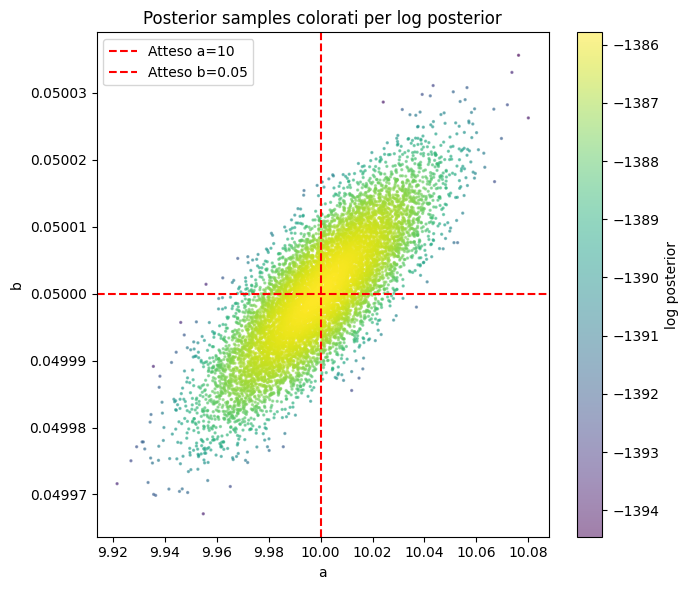

In [ ]:
# Calcola log_posterior per ogni sample
log_prob = np.array([log_posterior(s, x_mc, y_mc, err_mc) for s in samples])


fig, ax = plt.subplots(figsize=(7, 6))

sc = ax.scatter(samples[:, 0], samples[:, 1],
                c=log_prob,
                cmap='viridis',
                s=2, alpha=0.5)

plt.colorbar(sc, ax=ax, label='log posterior')

ax.axvline(10,   color='red', lw=1.5, linestyle='--', label='Atteso a=10')
ax.axhline(0.05, color='red', lw=1.5, linestyle='--', label='Atteso b=0.05')

ax.set_xlabel('a')
ax.set_ylabel('b')
ax.set_title('Posterior samples colorati per log posterior')
ax.legend()
plt.tight_layout()
plt.savefig("scatter_posterior.png", dpi=150)

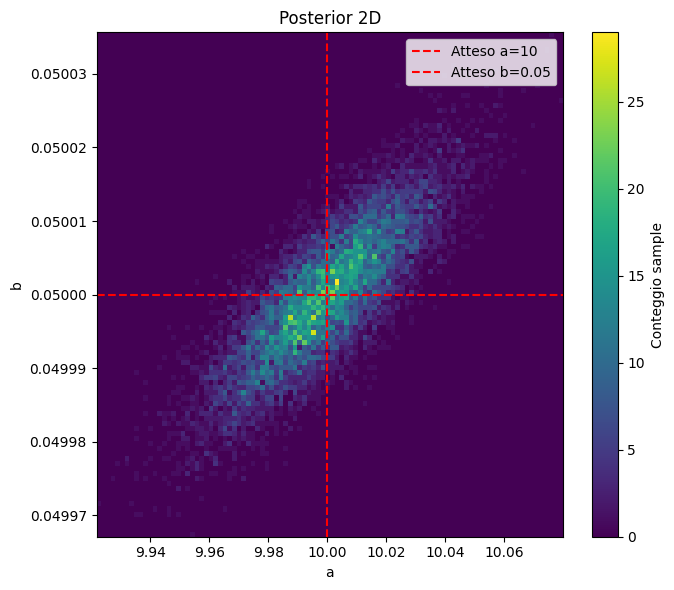

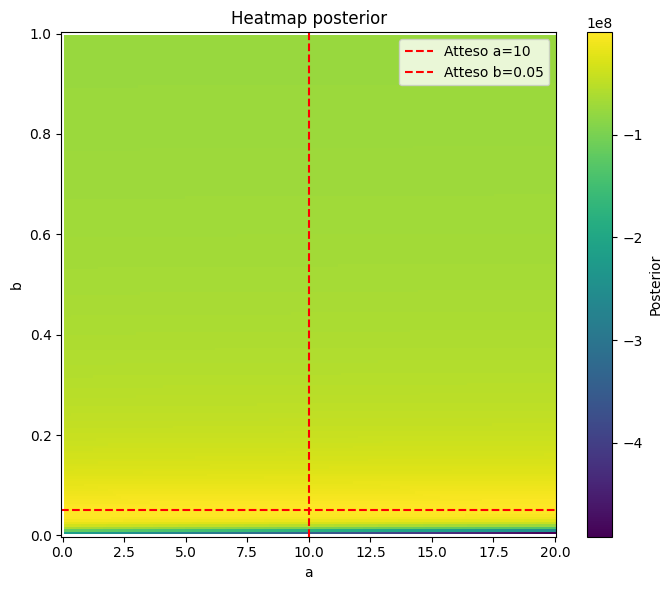

In [ ]:
# Opzione 1 — hist2d (più veloce)
fig, ax = plt.subplots(figsize=(7, 6))

h = ax.hist2d(samples[:, 0], samples[:, 1],
              bins=100, cmap='viridis')

plt.colorbar(h[3], ax=ax, label='Conteggio sample')
ax.axvline(10,   color='red', lw=1.5, linestyle='--', label='Atteso a=10')
ax.axhline(0.05, color='red', lw=1.5, linestyle='--', label='Atteso b=0.05')
ax.set_xlabel('a'); ax.set_ylabel('b')
ax.set_title('Posterior 2D')
ax.legend()
plt.tight_layout()
# plt.savefig("posterior_2d.png", dpi=150)
plt.show()


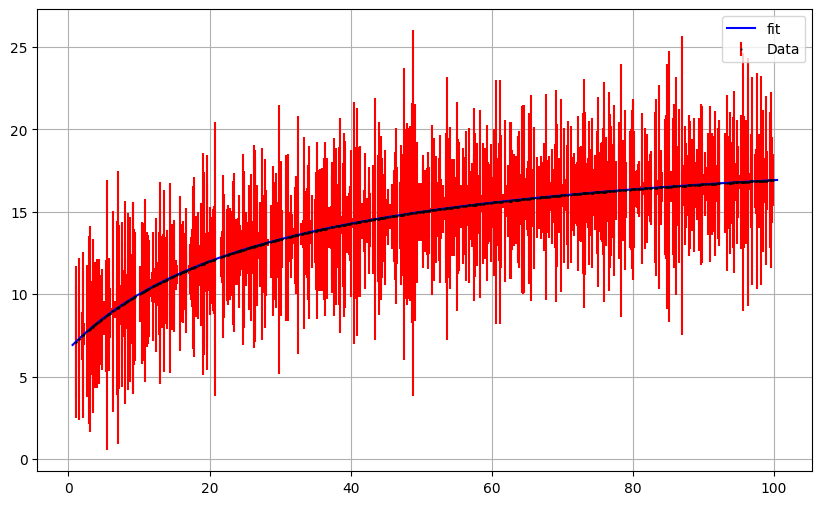

In [18]:
plt.figure(figsize=(10, 6))
plt.errorbar(C1_err, Ceq_err, DCeq_err, fmt='.k', ecolor='r', ms=1, ls='', label='Data')
plt.plot(x_plot, curve(x_plot, a_mcmc[1], b_mcmc[1]), label='fit', color='blue')
plt.grid(), plt.legend(),
plt.show()
